In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
clean_df = pd.read_csv(
    "../data/cleaned/online_retail_cleaned.csv",
    parse_dates=["InvoiceDate"]
)

clean_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


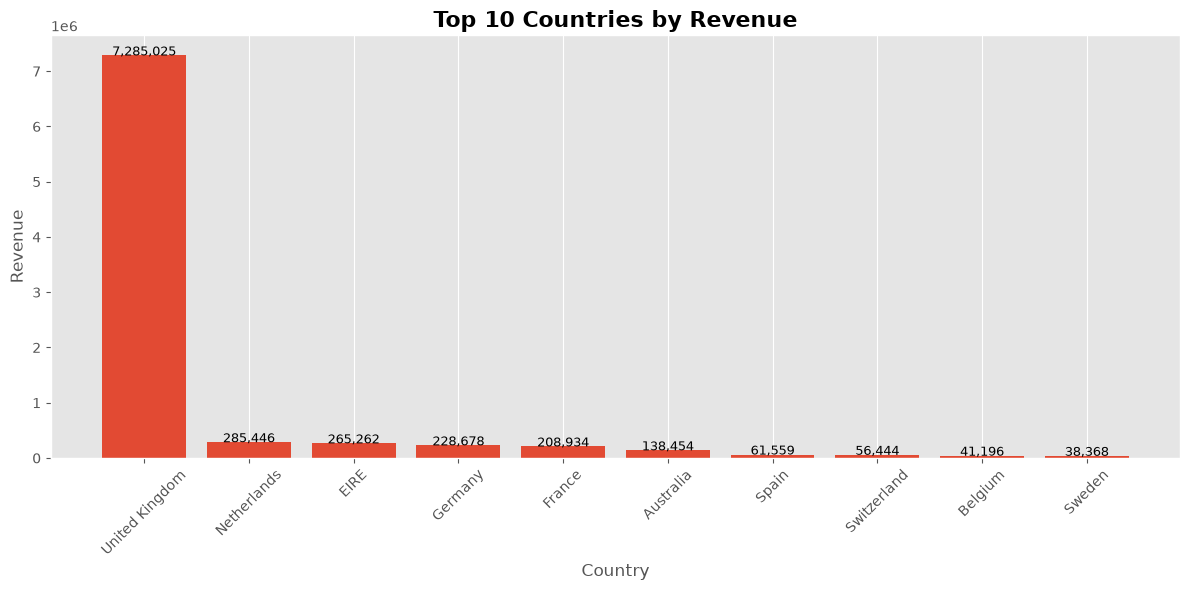

In [3]:
country_sales = (
    clean_df
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

bars = plt.bar(
    country_sales.index,
    country_sales.values
)

plt.title(
    "Top 10 Countries by Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Country")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(axis="y")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:,.0f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.show()

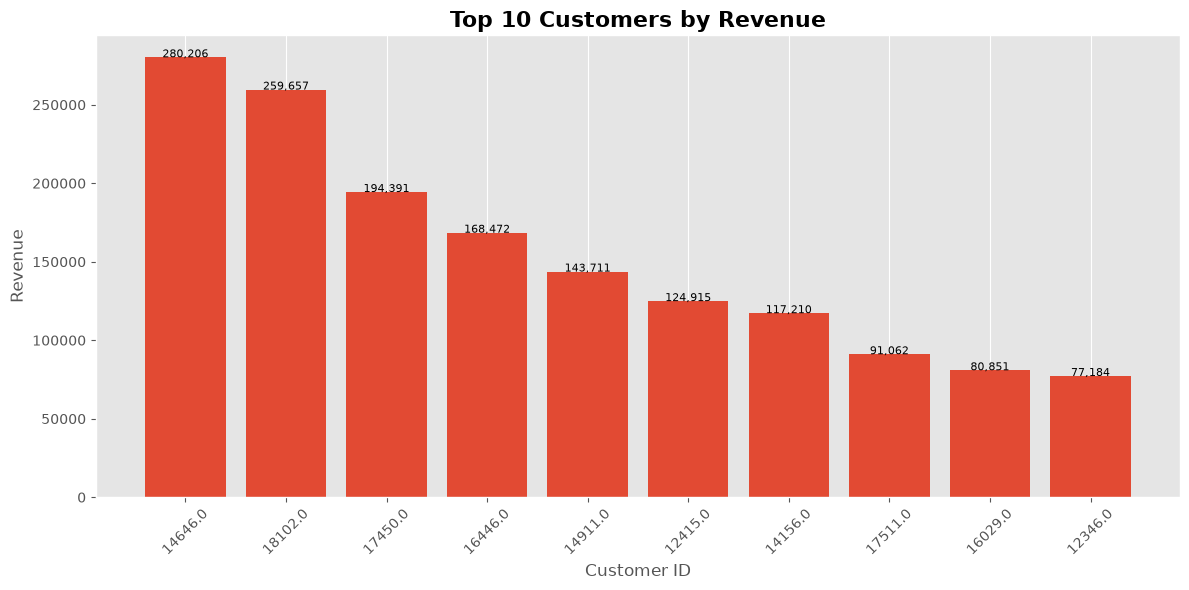

In [4]:
top_customers = (
    clean_df
    .groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

bars = plt.bar(
    top_customers.index.astype(str),
    top_customers.values
)

plt.title(
    "Top 10 Customers by Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer ID")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(axis="y")

for bar in bars:
    y = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        y,
        f"{y:,.0f}",
        ha="center",
        fontsize=8
    )

plt.tight_layout()

plt.show()

In [5]:
clean_df["Month"] = clean_df["InvoiceDate"].dt.to_period("M")

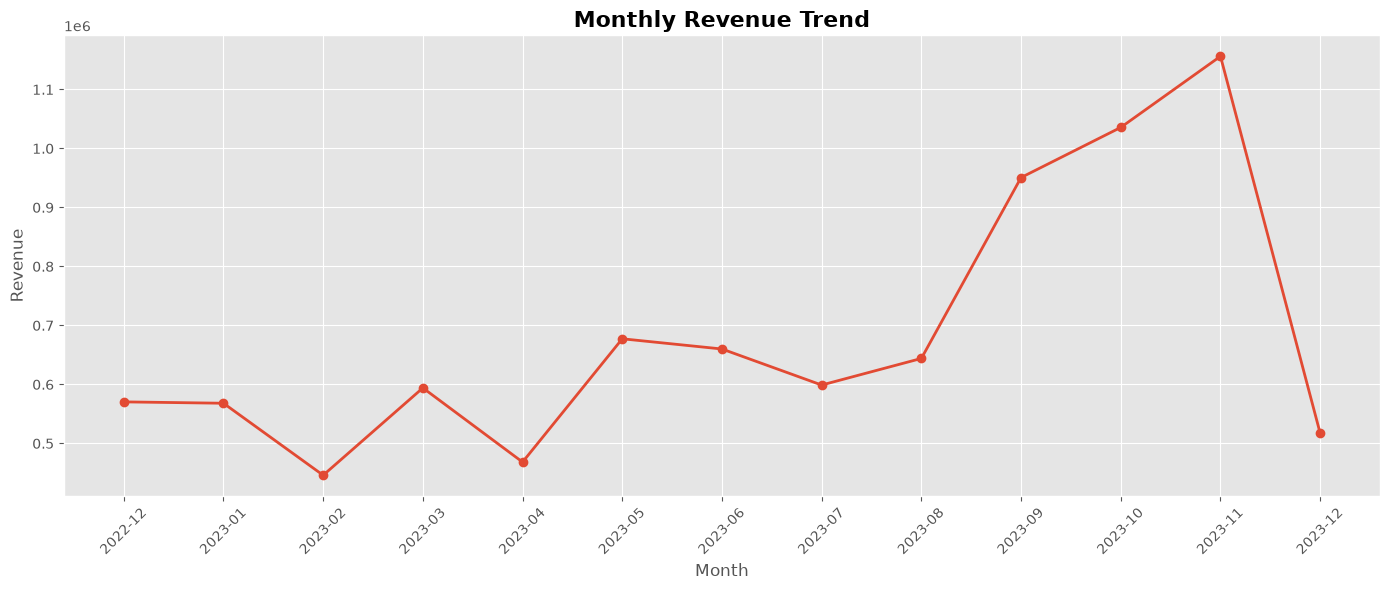

In [6]:
monthly_sales = (
    clean_df
    .groupby("Month")["Revenue"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly Revenue Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

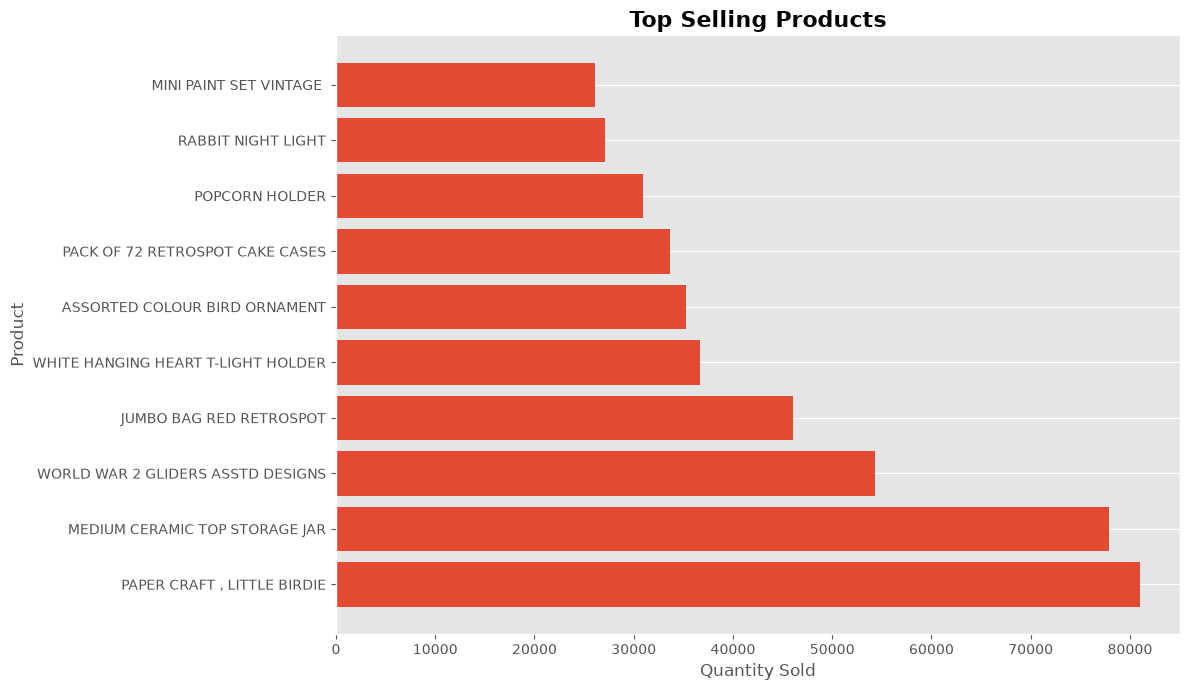

In [7]:
top_products = (
    clean_df
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,7))

bars = plt.barh(
    top_products.index,
    top_products.values
)

plt.title(
    "Top Selling Products",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Quantity Sold")

plt.ylabel("Product")

plt.grid(axis="x")

plt.tight_layout()

plt.show()

Revenue Summary Statistics
count    392692.000000
mean         22.631500
std         311.099224
min           0.001000
25%           4.950000
50%          12.450000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64

Revenue Skewness:
448.52


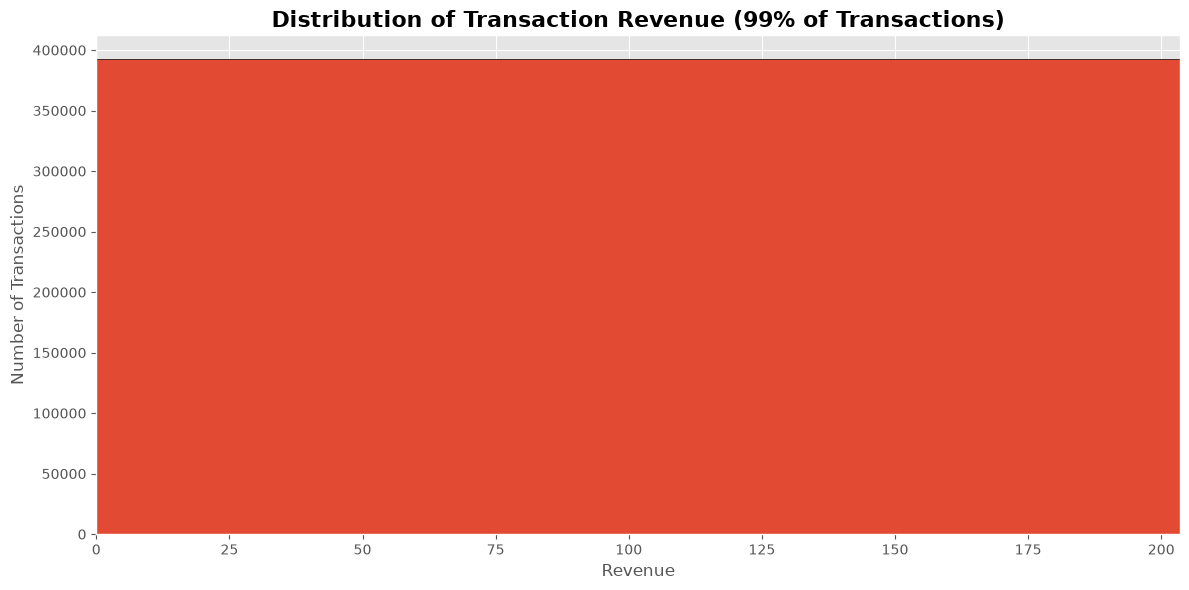

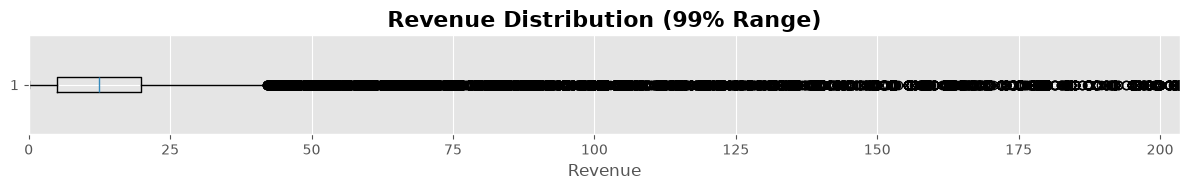

In [11]:
# ============================================================
# Revenue Distribution Analysis
# ============================================================

# Import required libraries
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Summary Statistics
# ------------------------------------------------------------

print("=" * 60)
print("Revenue Summary Statistics")
print("=" * 60)

print(clean_df["Revenue"].describe())

# ------------------------------------------------------------
# 2. Skewness
# ------------------------------------------------------------

print("\nRevenue Skewness:")
print(round(clean_df["Revenue"].skew(), 2))

# ------------------------------------------------------------
# 3. Histogram
# ------------------------------------------------------------

plt.figure(figsize=(12,6))

plt.hist(
    clean_df["Revenue"],
    bins=100,
    edgecolor="black"
)

# Zoom to the 99th percentile
plt.xlim(0, clean_df["Revenue"].quantile(0.99))

plt.title(
    "Distribution of Transaction Revenue (99% of Transactions)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Revenue")

plt.ylabel("Number of Transactions")

plt.grid(True)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 4. Boxplot
# ------------------------------------------------------------

plt.figure(figsize=(12,2))

plt.boxplot(
    clean_df["Revenue"],
    orientation="horizontal"   # replaces deprecated vert=False
)

plt.xlim(0, clean_df["Revenue"].quantile(0.99))

plt.title(
    "Revenue Distribution (99% Range)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Revenue")

plt.grid(True)

plt.tight_layout()

plt.show()

Business Question

How are transaction revenues distributed?

Why This Visualization?
    - Histogram shows the frequency of transaction values.
    - Boxplot highlights outliers and spread.
    - Summary statistics provide numerical context.

Interpretation
    - Most transactions are concentrated in the lower revenue range.
    - A small number of transactions have very high revenue.
    - The distribution is positively (right) skewed.

Business Insight
    - This pattern is common in e-commerce, where many customers make small purchases while a few place large or bulk orders.

Recommendation
    - Since K-Means clustering is sensitive to feature scale and outliers, we should:

Standardize or normalize features before clustering.
    - Investigate extreme values rather than removing them immediately, as they may represent valuable wholesale customers.

Key Takeaway
    - The revenue distribution is not normally distributed. Appropriate scaling and outlier assessment will be essential before machine learning.